PROCESO OPTIMIZADO CON MLP - RED ANCHA Y PROFUNDA (WIDE & DEEP)
BÚSQUEDA EXHAUSTIVA DE ARQUITECTURAS WIDE, DEEP Y WIDE&DEEP

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_95_5.xlsx
Datos de entrenamiento: 256 muestras, 115 características
INGENIERÍA DE ATRIBUTOS - RED ANCHA Y PROFUNDA
Escalando características...
Características después de ingeniería: 142

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS

Probando con 10 características...
  MAE: 9.8894, R²: 0.4636, RMSE: 15.3660
  MAE en picos (>P90): 20.6533

Probando con 15 características...
  MAE: 8.4819, R²: 0.6454, RMSE: 12.4947
  MAE en picos (>P90): 22.0055

Probando con 20 características...
  MAE: 8.5774, R²: 0.6273, RMSE: 12.8092
  MAE en picos (>P90): 18.9744

Probando con 25 características...
  MAE: 9.1507, R²: 0.6068, RMSE: 13.1567
  MAE en picos

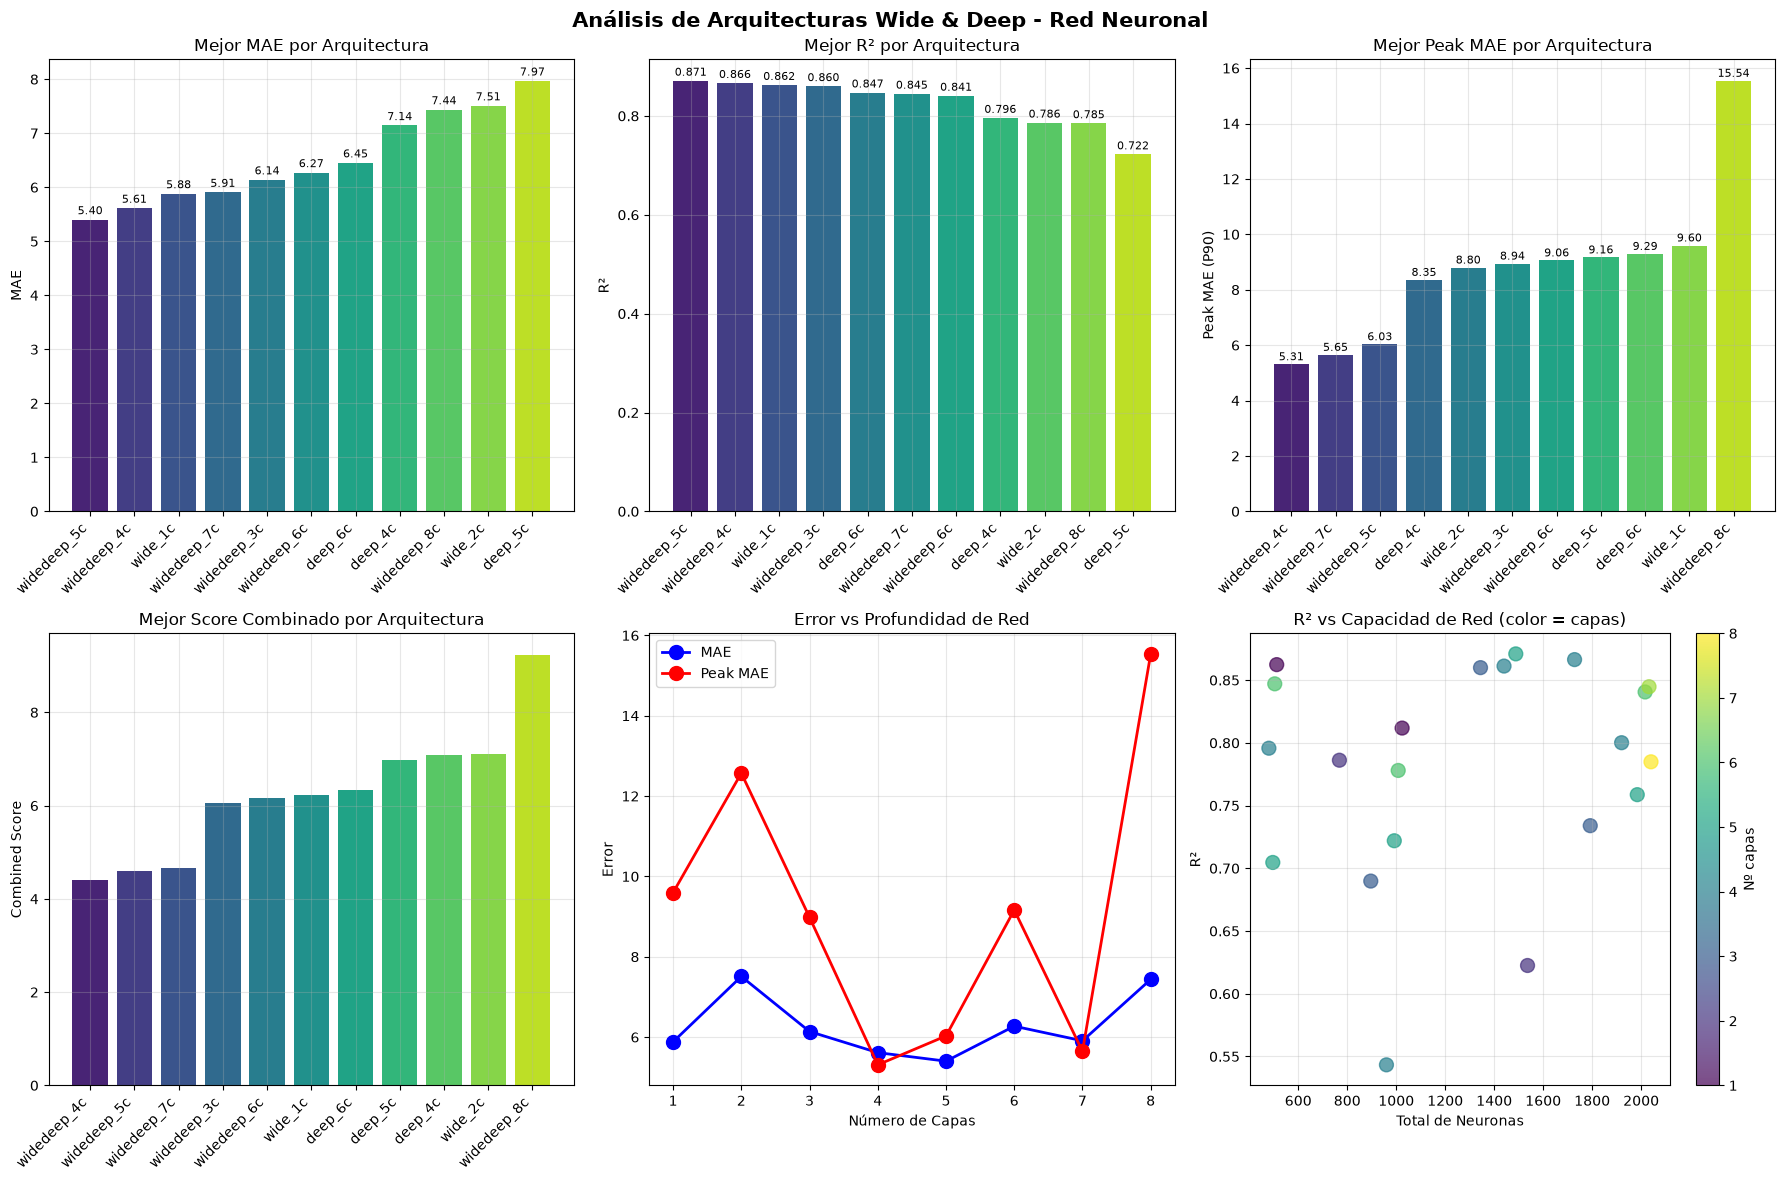

✅ Análisis Wide&Deep guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\wide_deep_tradeoff_20260917_174806.png


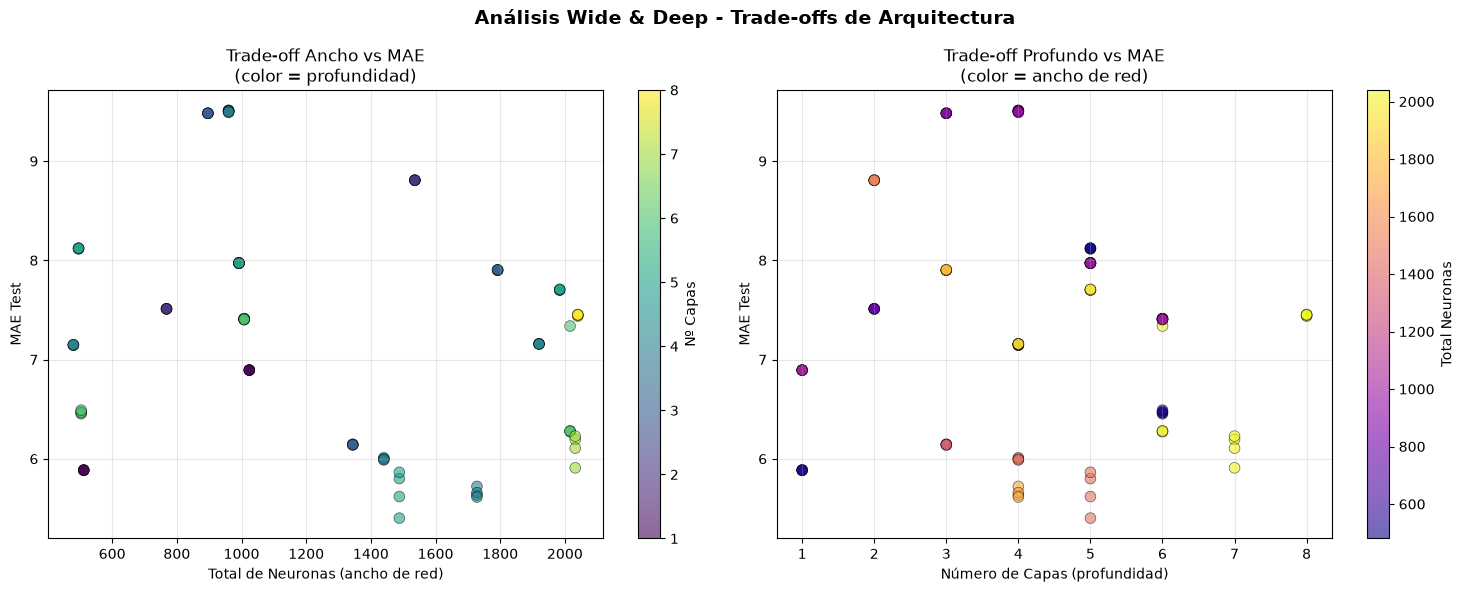

✅ Gráfico de selección guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\feature_selection_analysis_widedeep_20260917_174806.png


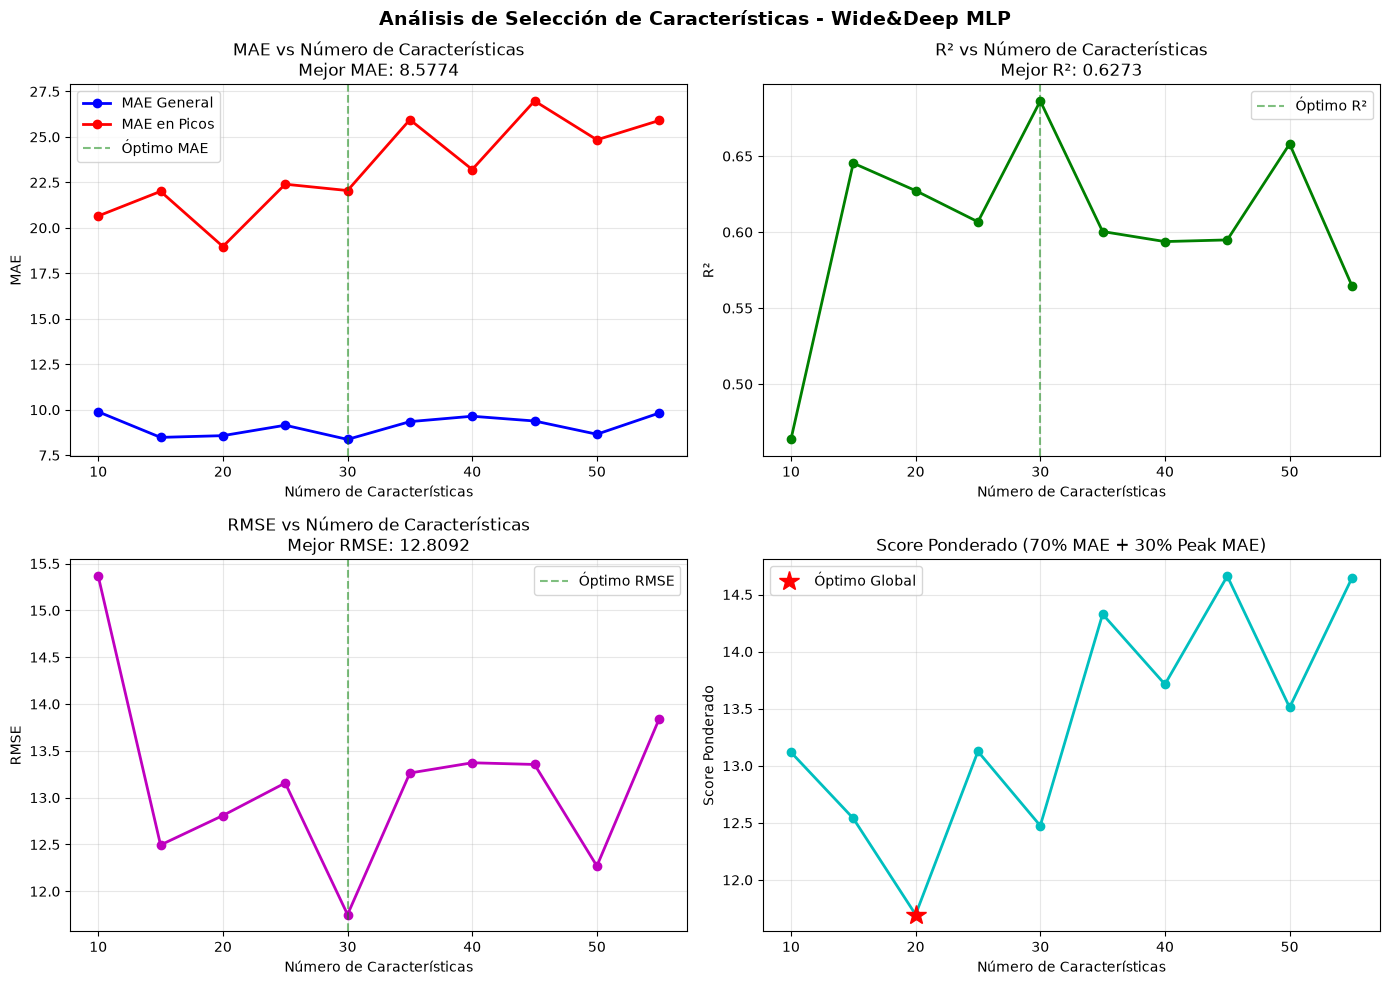

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\peak_analysis_widedeep_20260917_174806.png


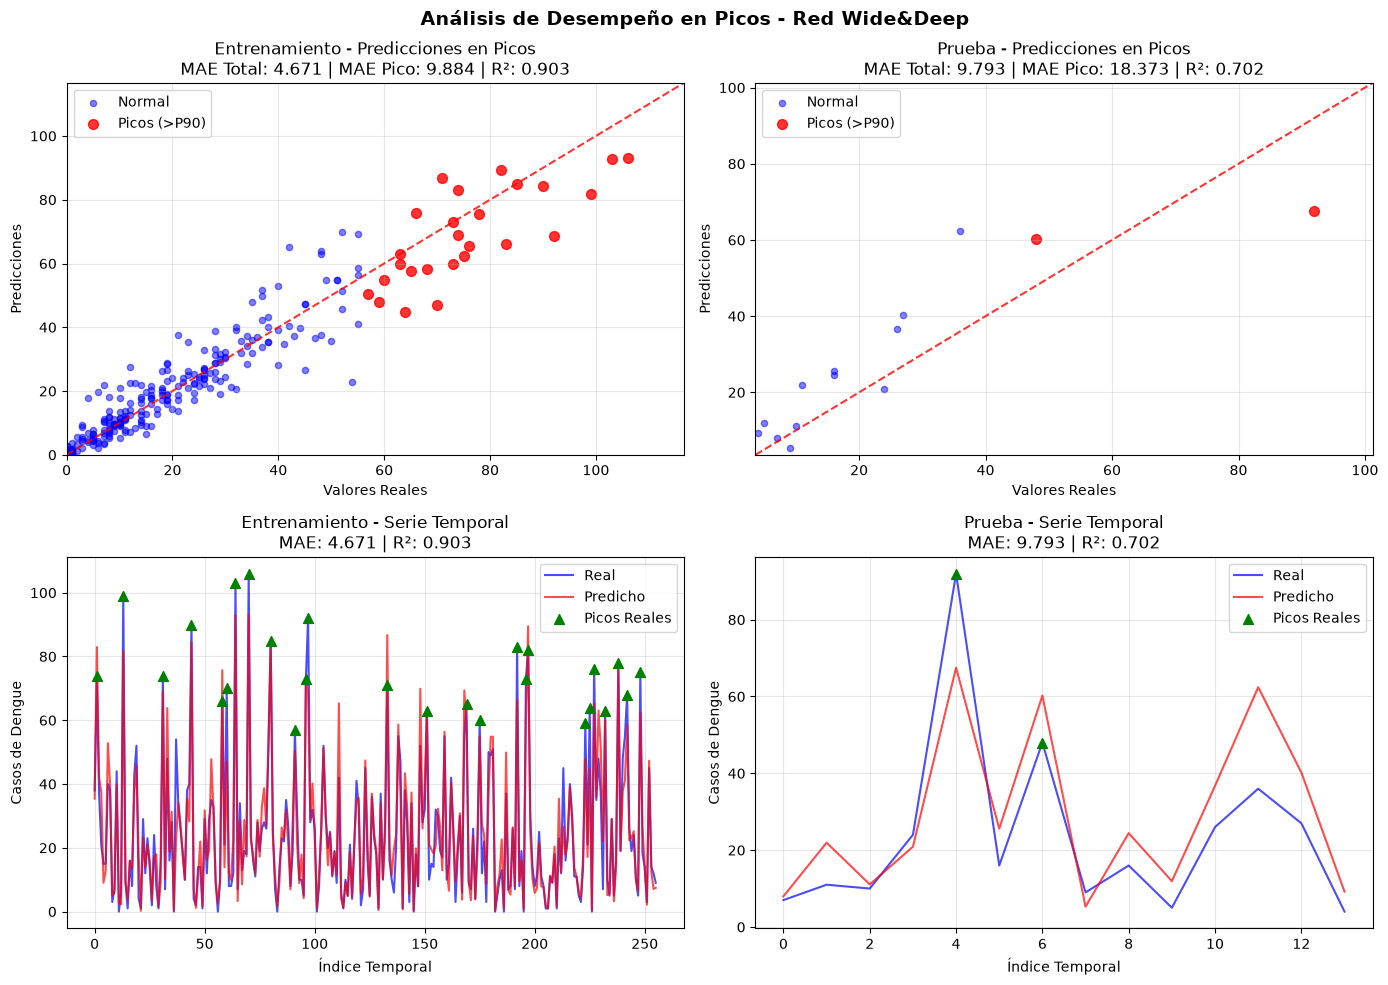

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\performance_comparison_widedeep_20260917_174806.png


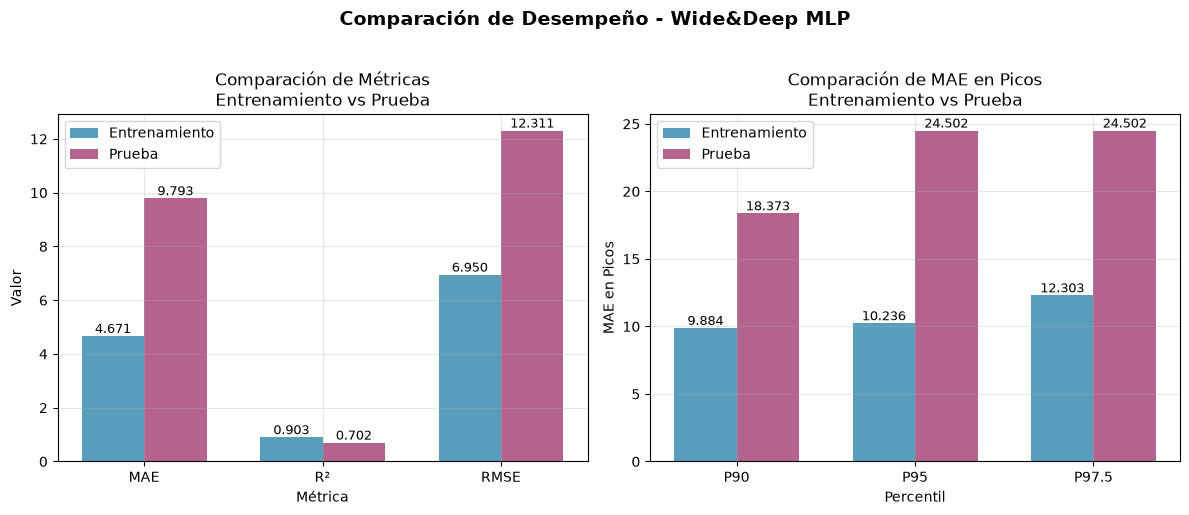

✅ Script de despliegue Wide&Deep generado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\modelo_mlp_widedeep_despliegue.py

PROCESO WIDE & DEEP COMPLETADO EXITOSAMENTE
Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\resultados_mlp_widedeep_20260917_174806.xlsx
Análisis de arquitecturas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi\architecture_analysis_widedeep_20260917_174806.png
Trade-off Wide/Deep: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resulta

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import warnings
import os
from datetime import datetime
import json
import pickle
from itertools import product
import time

warnings.filterwarnings('ignore')


class DengueFeatureEngineeringWideDeep:
    """
    Clase optimizada para ingeniería de atributos usando MLP (Red Neuronal)
    con búsqueda automática de la mejor arquitectura ANCHA Y PROFUNDA.

    Estrategia Wide & Deep:
    - Capas iniciales ANCHAS (muchas neuronas) para capturar patrones complejos
    - Capas posteriores PROFUNDAS (compresión progresiva) para abstracción
    - Regularización agresiva para evitar sobreajuste
    """
    def __init__(self, n_features_to_select=20):
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.mlp_model = None
        self.numeric_columns = None
        self.feature_importance_df = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.all_features_importance = None
        self.cv_results = None
        self.train_val_metrics = None
        self.architecture_results = None
        self.best_architecture = None

    def create_interaction_features(self, X):
        """Crea características de interacción seleccionadas estratégicamente"""
        interaction_data = pd.DataFrame(index=X.index)

        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]

        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]

        return interaction_data

    def create_polynomial_features(self, X):
        """Crea características polinomiales solo para variables clave"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)

        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2

        return poly_features

    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos con regularización"""
        lag_aggs = pd.DataFrame(index=X.index)

        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel',
                         'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns
                        if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)

        dengue_lag_cols = [col for col in X.columns
                           if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
            lag_aggs['dengue_lag_max'] = dengue_lag_data.max(axis=1)
            lag_aggs['dengue_lag_min'] = dengue_lag_data.min(axis=1)

        return lag_aggs

    def create_rolling_features(self, X):
        """Crea características de tendencia temporal simplificadas"""
        rolling_features = pd.DataFrame(index=X.index)

        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)

        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
                )
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']
                )

        return rolling_features

    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []

        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)

        return numeric_cols

    def augment_features(self, X):
        """Aplica ingeniería de atributos a cualquier conjunto de datos"""
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]

        features_list = [X_numeric]

        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)

        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)

        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)

        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)

        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        X_augmented = X_augmented.fillna(0)

        return X_augmented, X_numeric

    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("=" * 60)
        print("INGENIERÍA DE ATRIBUTOS - RED ANCHA Y PROFUNDA")
        print("=" * 60)

        X_augmented, X_numeric = self.augment_features(X)

        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()

        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        print(f"Características después de ingeniería: {X_augmented.shape[1]}")

        return X_scaled, X_augmented

    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_numeric = self.augment_features(X)

        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0

        X_augmented = X_augmented[self.X_augmented_columns]

        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        return X_scaled

    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """Encuentra el número óptimo de características con enfoque en picos"""
        if feature_range is None:
            feature_range = range(10, min(60, X_scaled.shape[1]), 5)

        print("\n" + "=" * 60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS")
        print("=" * 60)

        results = []
        best_mae = float('inf')
        best_peak_mae = float('inf')
        best_n_features = None
        best_rfe = None
        best_selected = None
        best_metrics = None

        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        for n_features in feature_range:
            print(f"\nProbando con {n_features} características...")

            rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )

            rfe = RFE(
                estimator=rf,
                n_features_to_select=n_features,
                step=3,
                verbose=0
            )

            X_train_selected = rfe.fit_transform(X_train_val, y_train_val)
            X_val_selected = rfe.transform(X_val)

            # MLP base ANCHO para evaluar (más capacidad)
            model = MLPRegressor(
                hidden_layer_sizes=(256, 128, 64),
                activation='relu',
                solver='adam',
                alpha=0.0005,
                batch_size='auto',
                learning_rate='adaptive',
                learning_rate_init=0.001,
                max_iter=500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20
            )
            model.fit(X_train_selected, y_train_val)

            y_pred = model.predict(X_val_selected)

            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            peak_threshold = np.percentile(y_val, 90)
            peak_mask = y_val > peak_threshold
            peak_mae = (mean_absolute_error(y_val[peak_mask], y_pred[peak_mask])
                        if np.sum(peak_mask) > 0 else float('inf'))

            print(f"  MAE: {mae:.4f}, R²: {r2:.4f}, RMSE: {rmse:.4f}")
            print(f"  MAE en picos (>P90): {peak_mae:.4f}")

            results.append({
                'n_features': n_features,
                'mae': mae,
                'r2': r2,
                'rmse': rmse,
                'peak_mae': peak_mae,
                'peak_threshold': peak_threshold,
                'n_peaks': int(np.sum(peak_mask))
            })

            weighted_score = (0.7 * mae + 0.3 * peak_mae
                              if peak_mae != float('inf') else mae)

            if weighted_score < best_mae:
                best_mae = weighted_score
                best_peak_mae = peak_mae
                best_n_features = n_features
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
                best_metrics = {
                    'mae': mae, 'r2': r2, 'rmse': rmse,
                    'peak_mae': peak_mae
                }

        print("\n" + "=" * 60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   MAE: {best_metrics['mae']:.4f}")
        print(f"   R²: {best_metrics['r2']:.4f}")
        print(f"   RMSE: {best_metrics['rmse']:.4f}")
        print(f"   MAE en picos: {best_metrics['peak_mae']:.4f}")
        print("=" * 60)

        self.selected_features = best_selected
        self.rfe = best_rfe
        self.best_metrics = best_metrics
        self.feature_selection_results = pd.DataFrame(results)

        return best_n_features, results, best_metrics

    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        return X_scaled[self.selected_features]

    def _build_wide_deep_architectures(self):
        """
        Construye un catálogo de arquitecturas ANCHAS Y PROFUNDAS.

        Estrategia:
        - Wide: capas iniciales con muchas neuronas (256-1024)
        - Deep: muchas capas apiladas (hasta 8)
        - Compresión progresiva: cada capa reduce a ~50% de la anterior
        - Combinaciones Wide&Deep: capa ancha inicial + varias profundas
        """
        architectures = {}

        # ========== WIDE PURO (1-2 capas, muchas neuronas) ==========
        architectures['wide_1c'] = {
            'hidden_layer_sizes': [
                (512,), (1024,),
            ],
            'desc': 'Wide - 1 capa ancha'
        }
        architectures['wide_2c'] = {
            'hidden_layer_sizes': [
                (1024, 512), (512, 256),
            ],
            'desc': 'Wide - 2 capas anchas'
        }

        # ========== DEEP PURO (muchas capas, compresión) ==========
        architectures['deep_4c'] = {
            'hidden_layer_sizes': [
                (256, 128, 64, 32),
                (512, 256, 128, 64),
            ],
            'desc': 'Deep - 4 capas comprimidas'
        }
        architectures['deep_5c'] = {
            'hidden_layer_sizes': [
                (256, 128, 64, 32, 16),
                (512, 256, 128, 64, 32),
            ],
            'desc': 'Deep - 5 capas comprimidas'
        }
        architectures['deep_6c'] = {
            'hidden_layer_sizes': [
                (512, 256, 128, 64, 32, 16),
                (256, 128, 64, 32, 16, 8),
            ],
            'desc': 'Deep - 6 capas comprimidas'
        }

        # ========== WIDE & DEEP (lo mejor de ambos) ==========
        architectures['widedeep_3c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256),
                (512, 256, 128),
                (768, 384, 192),
            ],
            'desc': 'Wide&Deep - 3 capas (ancha→media→profunda)'
        }
        architectures['widedeep_4c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256, 128),
                (512, 256, 128, 64),
                (768, 384, 192, 96),
                (1024, 512, 128, 64),
            ],
            'desc': 'Wide&Deep - 4 capas (ancha→profunda)'
        }
        architectures['widedeep_5c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256, 128, 64),
                (512, 256, 128, 64, 32),
                (768, 384, 192, 96, 48),
            ],
            'desc': 'Wide&Deep - 5 capas (ancha→profunda)'
        }
        architectures['widedeep_6c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256, 128, 64, 32),
                (512, 256, 128, 64, 32, 16),
            ],
            'desc': 'Wide&Deep - 6 capas (ancha→profunda)'
        }
        architectures['widedeep_7c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256, 128, 64, 32, 16),
            ],
            'desc': 'Wide&Deep - 7 capas (ancha→profunda)'
        }
        architectures['widedeep_8c'] = {
            'hidden_layer_sizes': [
                (1024, 512, 256, 128, 64, 32, 16, 8),
            ],
            'desc': 'Wide&Deep - 8 capas (muy ancha y profunda)'
        }

        return architectures

    def find_best_architecture(self, X_train, y_train, X_test, y_test):
        """
        Busca la mejor arquitectura de red neuronal ANCHA Y PROFUNDA
        evaluando diferentes números de capas y neuronas por capa.

        Estrategia Wide & Deep:
        - Capas iniciales anchas (capturan patrones complejos)
        - Capas profundas (abstracción jerárquica)
        - Regularización adaptativa según profundidad
        """
        print("\n" + "=" * 60)
        print("BÚSQUEDA DE LA MEJOR ARQUITECTURA ANCHA Y PROFUNDA")
        print("EVALUANDO WIDE, DEEP Y WIDE&DEEP")
        print("=" * 60)

        architectures = self._build_wide_deep_architectures()

        # Múltiples valores de alpha (regularización) para evitar sobreajuste
        # en redes anchas y profundas
        alpha_values = [0.0001, 0.0005, 0.001, 0.005]

        results = []
        total_configs = sum(len(arch['hidden_layer_sizes'])
                            for arch in architectures.values()) * len(alpha_values)
        print(f"\nEvaluando {total_configs} configuraciones Wide&Deep...")
        print("-" * 60)

        best_score = float('inf')
        best_config = None
        best_model = None
        best_metrics = None

        config_counter = 0

        for arch_name, arch_config in architectures.items():
            print(f"\n{arch_config['desc']} ({arch_name}):")

            for hidden_layers in arch_config['hidden_layer_sizes']:
                for alpha in alpha_values:
                    config_counter += 1
                    print(f"  [{config_counter}/{total_configs}] "
                          f"Capas: {hidden_layers}, alpha={alpha}",
                          end="", flush=True)

                    try:
                        start_time = time.time()

                        # Regularización adaptativa: más alpha para redes más profundas
                        n_layers = len(hidden_layers)
                        adaptive_alpha = alpha * (1 + 0.1 * n_layers)

                        model = MLPRegressor(
                            hidden_layer_sizes=hidden_layers,
                            activation='relu',
                            solver='adam',
                            alpha=adaptive_alpha,
                            learning_rate='adaptive',
                            learning_rate_init=0.001,
                            max_iter=1000,
                            random_state=42,
                            early_stopping=True,
                            validation_fraction=0.15,
                            n_iter_no_change=30,
                            batch_size='auto'
                        )
                        model.fit(X_train, y_train)
                        train_time = time.time() - start_time

                        # Evaluar
                        y_pred_test = model.predict(X_test)
                        y_pred_train = model.predict(X_train)

                        mae_test = mean_absolute_error(y_test, y_pred_test)
                        r2_test = r2_score(y_test, y_pred_test)
                        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
                        mae_train = mean_absolute_error(y_train, y_pred_train)
                        r2_train = r2_score(y_train, y_pred_train)

                        # MAE en picos
                        peak_threshold = np.percentile(y_test, 90)
                        peak_mask = y_test > peak_threshold
                        if np.sum(peak_mask) > 0:
                            peak_mae_test = mean_absolute_error(
                                y_test[peak_mask], y_pred_test[peak_mask]
                            )
                        else:
                            peak_mae_test = float('inf')

                        # Score combinado (prioriza MAE general y MAE en picos)
                        if peak_mae_test != float('inf'):
                            combined_score = (
                                0.4 * mae_test +
                                0.4 * peak_mae_test +
                                0.2 * (1 - r2_test)
                            )
                        else:
                            combined_score = (
                                0.6 * mae_test + 0.4 * (1 - r2_test)
                            )

                        # Penalización por sobreajuste excesivo
                        overfit_gap = abs(mae_test - mae_train)
                        if overfit_gap > 3.0:
                            combined_score *= 1.15

                        print(f" | MAE: {mae_test:.3f} | "
                              f"Peak MAE: {peak_mae_test:.3f} | "
                              f"R²: {r2_test:.3f} | "
                              f"Score: {combined_score:.3f} | "
                              f"Gap: {overfit_gap:.3f} | "
                              f"Tiempo: {train_time:.1f}s")

                        results.append({
                            'architecture': arch_name,
                            'desc': arch_config['desc'],
                            'layers': str(hidden_layers),
                            'n_layers': n_layers,
                            'neurons': hidden_layers,
                            'total_neurons': sum(hidden_layers),
                            'alpha': adaptive_alpha,
                            'mae_train': mae_train,
                            'r2_train': r2_train,
                            'mae_test': mae_test,
                            'r2_test': r2_test,
                            'rmse_test': rmse_test,
                            'peak_mae_test': peak_mae_test,
                            'overfit_gap': overfit_gap,
                            'combined_score': combined_score,
                            'train_time': train_time,
                            'model': model
                        })

                        if combined_score < best_score:
                            best_score = combined_score
                            best_config = {
                                'architecture': arch_name,
                                'desc': arch_config['desc'],
                                'hidden_layers': hidden_layers,
                                'n_layers': n_layers,
                                'neurons': hidden_layers,
                                'total_neurons': sum(hidden_layers),
                                'alpha': adaptive_alpha
                            }
                            best_model = model
                            best_metrics = {
                                'mae_train': mae_train,
                                'r2_train': r2_train,
                                'mae_test': mae_test,
                                'r2_test': r2_test,
                                'rmse_test': rmse_test,
                                'peak_mae_test': peak_mae_test,
                                'overfit_gap': overfit_gap,
                                'combined_score': combined_score,
                                'train_time': train_time
                            }

                    except Exception as e:
                        print(f" | Error: {str(e)[:60]}")
                        continue

        # Resumen
        print("\n" + "=" * 60)
        print("RESUMEN DE MEJORES MODELOS POR ARQUITECTURA")
        print("=" * 60)

        df_results = pd.DataFrame([
            {k: v for k, v in r.items() if k not in ('model', 'neurons')}
            for r in results
        ])

        if not df_results.empty:
            best_by_arch = df_results.loc[
                df_results.groupby('architecture')['combined_score'].idxmin()
            ]

            print("\nMejor modelo por tipo de arquitectura:")
            print("-" * 60)
            for _, row in best_by_arch.iterrows():
                print(f"  {row['architecture']}: "
                      f"MAE={row['mae_test']:.3f}, "
                      f"Peak MAE={row['peak_mae_test']:.3f}, "
                      f"R²={row['r2_test']:.3f}, "
                      f"Capas={row['layers']}")

            print("\nTop 10 mejores modelos generales:")
            print("-" * 60)
            top10 = df_results.nsmallest(10, 'combined_score')
            for idx, (_, row) in enumerate(top10.iterrows(), 1):
                print(f"  #{idx}: {row['architecture']} | "
                      f"Capas: {row['layers']} | "
                      f"alpha: {row['alpha']:.5f} | "
                      f"MAE: {row['mae_test']:.3f} | "
                      f"Peak MAE: {row['peak_mae_test']:.3f} | "
                      f"R²: {row['r2_test']:.3f} | "
                      f"Gap: {row['overfit_gap']:.3f}")

        self.architecture_results = pd.DataFrame(results)
        self.best_architecture = best_config
        self.mlp_model = best_model

        print("\n" + "=" * 60)
        print("✅ MEJOR ARQUITECTURA ANCHA Y PROFUNDA ENCONTRADA:")
        print("=" * 60)
        print(f"  Tipo: {best_config['desc']}")
        print(f"  Arquitectura: {best_config['architecture']}")
        print(f"  Capas ocultas: {best_config['hidden_layers']}")
        print(f"  Número de capas: {best_config['n_layers']}")
        print(f"  Neuronas por capa: {best_config['neurons']}")
        print(f"  Total neuronas: {best_config['total_neurons']}")
        print(f"  Alpha (regularización): {best_config['alpha']:.5f}")
        print(f"\n  MAE Test: {best_metrics['mae_test']:.4f}")
        print(f"  R² Test: {best_metrics['r2_test']:.4f}")
        print(f"  Peak MAE Test: {best_metrics['peak_mae_test']:.4f}")
        print(f"  Combined Score: {best_metrics['combined_score']:.4f}")
        print(f"  Brecha sobreajuste: {best_metrics['overfit_gap']:.4f}")
        print("=" * 60)

        self.best_metrics = {
            'mae': best_metrics['mae_test'],
            'r2': best_metrics['r2_test'],
            'rmse': best_metrics['rmse_test'],
            'peak_mae': best_metrics['peak_mae_test']
        }

        self.train_val_metrics = {
            'mae_train': best_metrics['mae_train'],
            'r2_train': best_metrics['r2_train'],
            'mae_test': best_metrics['mae_test'],
            'r2_test': best_metrics['r2_test'],
            'peak_mae_test': best_metrics['peak_mae_test'],
            'overfit_gap': best_metrics['overfit_gap'],
            'best_params': {
                'hidden_layer_sizes': best_config['hidden_layers'],
                'activation': 'relu',
                'solver': 'adam',
                'alpha': best_config['alpha'],
                'learning_rate': 'adaptive',
                'learning_rate_init': 0.001,
                'max_iter': 1000,
                'early_stopping': True,
                'validation_fraction': 0.15,
                'n_iter_no_change': 30
            }
        }

        return best_config, best_model, best_metrics

    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.mlp_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = (r2_score(y_test[peak_mask], y_pred[peak_mask])
                           if len(y_test[peak_mask]) > 1 else np.nan)
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = int(np.sum(peak_mask))

        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


# ==========================================
# FUNCIONES DE GRAFICACIÓN
# ==========================================

def plot_architecture_results(architecture_results, save_path=None):
    """Grafica los resultados de la búsqueda de arquitecturas Wide&Deep"""
    if architecture_results is None or len(architecture_results) == 0:
        print("No hay resultados de arquitecturas para graficar")
        return None

    df = architecture_results.copy()

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. MAE por arquitectura
    ax1 = axes[0, 0]
    architectures = df.groupby('architecture')['mae_test'].min().sort_values()
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(architectures)))
    bars = ax1.bar(range(len(architectures)), architectures.values,
                   color=colors)
    ax1.set_xticks(range(len(architectures)))
    ax1.set_xticklabels(architectures.index, rotation=45, ha='right')
    ax1.set_ylabel('MAE')
    ax1.set_title('Mejor MAE por Arquitectura')
    ax1.grid(True, alpha=0.3)
    for bar, val in zip(bars, architectures.values):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    # 2. R² por arquitectura
    ax2 = axes[0, 1]
    r2_scores = df.groupby('architecture')['r2_test'].max().sort_values(ascending=False)
    bars = ax2.bar(range(len(r2_scores)), r2_scores.values,
                   color=colors)
    ax2.set_xticks(range(len(r2_scores)))
    ax2.set_xticklabels(r2_scores.index, rotation=45, ha='right')
    ax2.set_ylabel('R²')
    ax2.set_title('Mejor R² por Arquitectura')
    ax2.grid(True, alpha=0.3)
    for bar, val in zip(bars, r2_scores.values):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    # 3. Peak MAE por arquitectura
    ax3 = axes[0, 2]
    peak_mae = df.groupby('architecture')['peak_mae_test'].min().sort_values()
    bars = ax3.bar(range(len(peak_mae)), peak_mae.values,
                   color=colors)
    ax3.set_xticks(range(len(peak_mae)))
    ax3.set_xticklabels(peak_mae.index, rotation=45, ha='right')
    ax3.set_ylabel('Peak MAE (P90)')
    ax3.set_title('Mejor Peak MAE por Arquitectura')
    ax3.grid(True, alpha=0.3)
    for bar, val in zip(bars, peak_mae.values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    # 4. Combined Score por arquitectura
    ax4 = axes[1, 0]
    score = df.groupby('architecture')['combined_score'].min().sort_values()
    bars = ax4.bar(range(len(score)), score.values, color=colors)
    ax4.set_xticks(range(len(score)))
    ax4.set_xticklabels(score.index, rotation=45, ha='right')
    ax4.set_ylabel('Combined Score')
    ax4.set_title('Mejor Score Combinado por Arquitectura')
    ax4.grid(True, alpha=0.3)

    # 5. Número de capas vs MAE
    ax5 = axes[1, 1]
    best_per_layers = df.loc[
        df.groupby('n_layers')['mae_test'].idxmin()
    ].sort_values('n_layers')
    ax5.plot(best_per_layers['n_layers'], best_per_layers['mae_test'],
             'bo-', linewidth=2, markersize=10, label='MAE')
    ax5.plot(best_per_layers['n_layers'], best_per_layers['peak_mae_test'],
             'ro-', linewidth=2, markersize=10, label='Peak MAE')
    ax5.set_xlabel('Número de Capas')
    ax5.set_ylabel('Error')
    ax5.set_title('Error vs Profundidad de Red')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Total de neuronas vs R²
    ax6 = axes[1, 2]
    best_per_neurons = df.loc[
        df.groupby('total_neurons')['r2_test'].idxmax()
    ].sort_values('total_neurons')
    ax6.scatter(best_per_neurons['total_neurons'],
                best_per_neurons['r2_test'],
                c=best_per_neurons['n_layers'], cmap='viridis',
                s=100, alpha=0.7)
    ax6.set_xlabel('Total de Neuronas')
    ax6.set_ylabel('R²')
    ax6.set_title('R² vs Capacidad de Red (color = capas)')
    ax6.grid(True, alpha=0.3)
    plt.colorbar(ax6.collections[0], ax=ax6, label='Nº capas')

    plt.suptitle('Análisis de Arquitecturas Wide & Deep - Red Neuronal',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de arquitecturas guardado en: {save_path}")

    plt.show()
    return fig


def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    df = pd.DataFrame(results)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. MAE vs Número de características
    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE General', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='MAE en Picos', linewidth=2)
    ax1.axvline(x=df.loc[df['mae'].idxmin(), 'n_features'],
                color='g', linestyle='--', alpha=0.5, label='Óptimo MAE')
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('MAE')
    ax1.set_title(f'MAE vs Número de Características\n'
                  f'Mejor MAE: {best_metrics["mae"]:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. R² vs Número de características
    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.axvline(x=df.loc[df['r2'].idxmax(), 'n_features'],
                color='g', linestyle='--', alpha=0.5, label='Óptimo R²')
    ax2.set_xlabel('Número de Características')
    ax2.set_ylabel('R²')
    ax2.set_title(f'R² vs Número de Características\n'
                  f'Mejor R²: {best_metrics["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. RMSE vs Número de características
    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.axvline(x=df.loc[df['rmse'].idxmin(), 'n_features'],
                color='g', linestyle='--', alpha=0.5, label='Óptimo RMSE')
    ax3.set_xlabel('Número de Características')
    ax3.set_ylabel('RMSE')
    ax3.set_title(f'RMSE vs Número de Características\n'
                  f'Mejor RMSE: {best_metrics["rmse"]:.4f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Score ponderado
    ax4 = axes[1, 1]
    weighted_score = 0.7 * df['mae'] + 0.3 * df['peak_mae']
    ax4.plot(df['n_features'], weighted_score, 'co-', linewidth=2)
    min_idx = weighted_score.idxmin()
    ax4.plot(df['n_features'][min_idx], weighted_score[min_idx],
             'r*', markersize=15, label='Óptimo Global')
    ax4.set_xlabel('Número de Características')
    ax4.set_ylabel('Score Ponderado')
    ax4.set_title('Score Ponderado (70% MAE + 30% Peak MAE)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Selección de Características - Wide&Deep MLP',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")

    plt.show()
    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train

    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--',
             alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Entrenamiento - Predicciones en Picos\n'
                  f'MAE Total: {train_metrics["MAE"]:.3f} | '
                  f'MAE Pico: {peak_mae_train:.3f} | '
                  f'R²: {train_metrics["R2"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)

    # 2. Predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test

    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--',
             alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Prueba - Predicciones en Picos\n'
                  f'MAE Total: {test_metrics["MAE"]:.3f} | '
                  f'MAE Pico: {peak_mae_test:.3f} | '
                  f'R²: {test_metrics["R2"]:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)

    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-',
             label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-',
             label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train],
                color='green', s=50, marker='^',
                label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title(f'Entrenamiento - Serie Temporal\n'
                  f'MAE: {train_metrics["MAE"]:.3f} | '
                  f'R²: {train_metrics["R2"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-',
             label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-',
             label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test],
                color='green', s=50, marker='^',
                label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title(f'Prueba - Serie Temporal\n'
                  f'MAE: {test_metrics["MAE"]:.3f} | '
                  f'R²: {test_metrics["R2"]:.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Desempeño en Picos - Red Wide&Deep',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")

    plt.show()
    return fig


def plot_wide_deep_analysis(architecture_results, save_path=None):
    """
    Gráfico específico para analizar el trade-off Wide vs Deep
    """
    if architecture_results is None or len(architecture_results) == 0:
        return None

    df = architecture_results.copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Total neuronas vs MAE (coloreado por capas)
    ax1 = axes[0]
    scatter = ax1.scatter(df['total_neurons'], df['mae_test'],
                          c=df['n_layers'], cmap='viridis',
                          s=60, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax1.set_xlabel('Total de Neuronas (ancho de red)')
    ax1.set_ylabel('MAE Test')
    ax1.set_title('Trade-off Ancho vs MAE\n(color = profundidad)')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Nº Capas')

    # 2. Profundidad vs MAE (coloreado por ancho)
    ax2 = axes[1]
    scatter = ax2.scatter(df['n_layers'], df['mae_test'],
                          c=df['total_neurons'], cmap='plasma',
                          s=60, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax2.set_xlabel('Número de Capas (profundidad)')
    ax2.set_ylabel('MAE Test')
    ax2.set_title('Trade-off Profundo vs MAE\n(color = ancho de red)')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='Total Neuronas')

    plt.suptitle('Análisis Wide & Deep - Trade-offs de Arquitectura',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis Wide&Deep guardado en: {save_path}")

    plt.show()
    return fig


def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño entre entrenamiento y prueba"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Comparación de métricas
    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
    test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax1.bar(x - width/2, train_values, width,
                    label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_values, width,
                    label='Prueba', color='#A23B72', alpha=0.8)

    ax1.set_xlabel('Métrica')
    ax1.set_ylabel('Valor')
    ax1.set_title('Comparación de Métricas\nEntrenamiento vs Prueba')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. Comparación de MAE en picos
    ax2 = axes[1]
    peak_percentiles = [90, 95, 97.5]
    train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0)
                      for p in peak_percentiles]
    test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0)
                     for p in peak_percentiles]

    x = np.arange(len(peak_percentiles))
    width = 0.35

    bars1 = ax2.bar(x - width/2, train_peak_mae, width,
                    label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_peak_mae, width,
                    label='Prueba', color='#A23B72', alpha=0.8)

    ax2.set_xlabel('Percentil')
    ax2.set_ylabel('MAE en Picos')
    ax2.set_title('Comparación de MAE en Picos\nEntrenamiento vs Prueba')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Comparación de Desempeño - Wide&Deep MLP',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")

    plt.show()
    return fig


def save_detailed_results(results, feature_results, architecture_results,
                          best_metrics, selected_features, feature_importance,
                          best_params, train_val_metrics, filepath):
    """Guarda resultados detallados en Excel incluyendo arquitecturas evaluadas"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            # Métricas generales
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)

            # Métricas de picos
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)

            # Características seleccionadas
            df_selected_features = pd.DataFrame({
                'Feature': selected_features,
                'Importance': (feature_importance
                               if len(feature_importance) == len(selected_features)
                               else [0] * len(selected_features))
            }).sort_values('Importance', ascending=False)
            df_selected_features.to_excel(
                writer, sheet_name='Características_Seleccionadas', index=False)

            # Métricas del mejor modelo
            df_best_metrics = pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'],
                          best_metrics['rmse'], best_metrics['peak_mae']]
            })
            df_best_metrics.to_excel(writer,
                                     sheet_name='Mejor_Modelo_Métricas',
                                     index=False)

            # Hiperparámetros
            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': [str(v) if isinstance(v, tuple) else v
                              for v in best_params.values()]
                })
                df_params.to_excel(writer,
                                   sheet_name='Mejores_Hiperparámetros',
                                   index=False)

            # Arquitecturas evaluadas
            if architecture_results is not None and len(architecture_results) > 0:
                arch_df = architecture_results.copy()
                arch_df = arch_df.drop(columns=['model', 'neurons'],
                                       errors='ignore')
                arch_df.to_excel(writer,
                                 sheet_name='Arquitecturas_WideDeep',
                                 index=False)

            # Validación
            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train',
                                'R² Test', 'Peak MAE Test',
                                'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics.get('mae_train', np.nan),
                        train_val_metrics.get('mae_test', np.nan),
                        train_val_metrics.get('r2_train', np.nan),
                        train_val_metrics.get('r2_test', np.nan),
                        train_val_metrics.get('peak_mae_test', np.nan),
                        train_val_metrics.get('overfit_gap', np.nan)
                    ]
                })
                df_tuning.to_excel(writer,
                                   sheet_name='Validación_Hiperparámetros',
                                   index=False)

            # Búsqueda de features
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer,
                                           sheet_name='Búsqueda_Features',
                                           index=False)

            # Predicciones
            max_len = max(len(results['train']['actual']),
                          len(results['test']['actual']))
            train_actual = np.pad(
                results['train']['actual'],
                (0, max_len - len(results['train']['actual'])),
                constant_values=np.nan)
            train_pred = np.pad(
                results['train']['predictions'],
                (0, max_len - len(results['train']['predictions'])),
                constant_values=np.nan)
            test_actual = np.pad(
                results['test']['actual'],
                (0, max_len - len(results['test']['actual'])),
                constant_values=np.nan)
            test_pred = np.pad(
                results['test']['predictions'],
                (0, max_len - len(results['test']['predictions'])),
                constant_values=np.nan)

            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer,
                                    sheet_name='Predicciones',
                                    index=False)

        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


def generate_deployment_script(engine, output_dir, base_path):
    """Genera un script Python para implementar el modelo entrenado"""

    script_content = '''"""
Script de despliegue del modelo MLP Wide&Deep para predicción de casos de dengue
Generado automáticamente - {fecha}

Este script permite cargar el modelo entrenado y realizar predicciones
sobre nuevos datos con el mismo formato que los datos de entrenamiento.
"""

import pandas as pd
import numpy as np
import pickle
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


class DengueModelDeployment:
    """
    Clase para desplegar el modelo MLP Wide&Deep de predicción de casos de dengue
    """
    def __init__(self, model_dir):
        self.model_dir = model_dir
        self.load_model()

    def load_model(self):
        with open(os.path.join(self.model_dir, 'scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)

        with open(os.path.join(self.model_dir, 'mlp_model.pkl'), 'rb') as f:
            self.mlp_model = pickle.load(f)

        with open(os.path.join(self.model_dir, 'model_config.json'), 'r') as f:
            config = json.load(f)
            self.selected_features = config['selected_features']
            self.X_augmented_columns = config['X_augmented_columns']
            self.best_params = config.get('best_params', {})
            self.best_architecture = config.get('best_architecture', {})

        print("✅ Modelo MLP Wide&Deep cargado exitosamente")
        print(f"   Características seleccionadas: {len(self.selected_features)}")
        print(f"   Arquitectura: {self.best_architecture.get('hidden_layers', 'No especificada')}")
        print(f"   Tipo: {self.best_architecture.get('desc', 'No especificado')}")

    def _create_interaction_features(self, X):
        interaction_data = pd.DataFrame(index=X.index)
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        return interaction_data

    def _create_polynomial_features(self, X):
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        for var in important_vars:
            if var in X.columns:
                poly_features[var + '_squared'] = X[var] ** 2
        return poly_features

    def _create_lag_aggregates(self, X):
        lag_aggs = pd.DataFrame(index=X.index)
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel',
                         'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns
                        if col.startswith(base_var + '_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[base_var + '_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[base_var + '_lag_std'] = lag_data.std(axis=1)
        dengue_lag_cols = [col for col in X.columns
                           if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
        return lag_aggs

    def _create_rolling_features(self, X):
        rolling_features = pd.DataFrame(index=X.index)
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_8'])
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = (
                    X['casos_dengue_lag_12'] - X['casos_dengue_lag_4'])
        return rolling_features

    def _get_numeric_columns(self, X):
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        return numeric_cols

    def _augment_features(self, X):
        numeric_cols = self._get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        features_list = [X_numeric]

        interaction_features = self._create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        poly_features = self._create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        lag_aggs = self._create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        rolling_features = self._create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        X_augmented = X_augmented.fillna(0)
        return X_augmented

    def predict(self, X):
        X_augmented = self._augment_features(X)
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        X_augmented = X_augmented[self.X_augmented_columns]
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        X_final = X_scaled[self.selected_features]
        predictions = self.mlp_model.predict(X_final)
        return predictions

    def predict_and_save(self, X, output_path=None):
        predictions = self.predict(X)
        results_df = X.copy()
        results_df['prediccion_casos_dengue'] = predictions
        if output_path:
            results_df.to_excel(output_path, index=False)
            print(f"✅ Predicciones guardadas en: {output_path}")
        return results_df


if __name__ == "__main__":
    print("="*60)
    print("SCRIPT DE DESPLIEGUE - MODELO Wide&Deep DENGUE")
    print("="*60)

    model_dir = r"{model_dir}"
    model = DengueModelDeployment(model_dir)

    print("\\nCargando datos de prueba...")
    test_path = r"{test_path}"
    test_data = pd.read_excel(test_path)
    X_test = test_data.drop('casos_dengue', axis=1)

    print("Realizando predicciones...")
    predictions = model.predict(X_test)

    print(f"Predicciones generadas para {len(predictions)} muestras")
    print(f"  Media: {np.mean(predictions):.2f}")
    print(f"  Mediana: {np.median(predictions):.2f}")
    print(f"  Mínimo: {np.min(predictions):.2f}")
    print(f"  Máximo: {np.max(predictions):.2f}")

    output_path = os.path.join(model_dir, "predicciones_ejemplo.xlsx")
    model.predict_and_save(X_test, output_path)
'''

    script_content = script_content.replace(
        '{fecha}', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

    script_path = os.path.join(output_dir,
                               "modelo_mlp_widedeep_despliegue.py")

    model_dir_abs = os.path.join(output_dir,
                                 "modelo_mlp_widedeep_guardado")
    test_path_abs = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")

    script_content = script_content.replace('{model_dir}', model_dir_abs)
    script_content = script_content.replace('{test_path}', test_path_abs)

    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)

    print(f"✅ Script de despliegue Wide&Deep generado en: {script_path}")
    return script_path


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("=" * 60)
    print("PROCESO OPTIMIZADO CON MLP - RED ANCHA Y PROFUNDA (WIDE & DEEP)")
    print("BÚSQUEDA EXHAUSTIVA DE ARQUITECTURAS WIDE, DEEP Y WIDE&DEEP")
    print("=" * 60)

    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5"
    output_dir = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_red_neuronal_mlp_ancha_profunda\2_datos\1_raw\3_95_5\1_resultados_mlp_ancha_profunda_95_5_meteo_epi"

    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Cargar datos de entrenamiento
    train_path = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_95_5.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)

    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']

    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, "
          f"{X_train.shape[1]} características")

    # Inicializar y aplicar ingeniería de atributos
    engine = DengueFeatureEngineeringWideDeep()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)

    # Buscar número óptimo de características
    feature_range = range(10, min(60, X_scaled.shape[1]), 5)
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(
        X_scaled, y_train, feature_range
    )

    # División para tuning (90/10)
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.1, random_state=42
    )

    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)

    # Buscar mejor arquitectura Wide&Deep
    best_config, model, arch_metrics = engine.find_best_architecture(
        X_train_selected, y_train_tune, X_test_selected, y_test_tune
    )

    # Evaluar en entrenamiento completo
    print("\n" + "=" * 60)
    print("EVALUANDO MODELO Wide&Deep EN DATOS DE ENTRENAMIENTO")
    print("=" * 60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(
        X_train_full_selected, y_train, "Train")

    # Cargar datos de prueba reales
    test_path = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_95_5.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)

    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']

    print(f"Datos de prueba: {X_test.shape[0]} muestras, "
          f"{X_test.shape[1]} características")

    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)

    # Evaluar en prueba
    print("\n" + "=" * 60)
    print("EVALUANDO MODELO Wide&Deep EN DATOS DE PRUEBA REALES")
    print("=" * 60)
    test_metrics = engine.evaluate_model_detailed(
        X_test_selected_final, y_test, "Test")

    # Resumen final
    print("\n" + "=" * 60)
    print("RESUMEN FINAL - ARQUITECTURA WIDE & DEEP OPTIMIZADA")
    print("=" * 60)
    print(f"Tipo: {best_config['desc']}")
    print(f"Arquitectura: {best_config['architecture']}")
    print(f"Capas ocultas: {best_config['hidden_layers']}")
    print(f"Número de capas: {best_config['n_layers']}")
    print(f"Total neuronas: {best_config['total_neurons']}")
    print(f"Alpha (regularización): {best_config['alpha']:.5f}")
    print(f"\nTrain - MAE: {train_metrics['MAE']:.4f}, "
          f"R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, "
          f"R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")

    overfit_gap_final = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste final: {overfit_gap_final:.4f}")

    # Verificar objetivos
    print("\n" + "-" * 60)
    print("VERIFICACIÓN DE OBJETIVOS:")
    print("-" * 60)

    target_mae_train = train_metrics['MAE'] < 3
    target_mae_test = test_metrics['MAE'] < 3
    target_peak_test = test_metrics['peak_metrics'].get('P90_MAE', 999) < 8
    target_r2_train = train_metrics['R2'] > 0.9
    target_r2_test = test_metrics['R2'] > 0.85

    print(f"MAE < 3 (Train):      {'✅' if target_mae_train else '❌'}  "
          f"({train_metrics['MAE']:.4f})")
    print(f"MAE < 3 (Test):       {'✅' if target_mae_test else '❌'}  "
          f"({test_metrics['MAE']:.4f})")
    print(f"Peak MAE < 8 (Test):  {'✅' if target_peak_test else '❌'}  "
          f"({test_metrics['peak_metrics'].get('P90_MAE', 0):.4f})")
    print(f"R² > 0.9 (Train):     {'✅' if target_r2_train else '❌'}  "
          f"({train_metrics['R2']:.4f})")
    print(f"R² > 0.85 (Test):     {'✅' if target_r2_test else '❌'}  "
          f"({test_metrics['R2']:.4f})")

    if overfit_gap_final < 2:
        print(f"Brecha < 2:           ✅  ({overfit_gap_final:.4f})")
    else:
        print(f"Brecha < 2:           ❌  ({overfit_gap_final:.4f})")

    # Guardar resultados
    results = {'train': train_metrics, 'test': test_metrics}

    excel_output = os.path.join(
        output_dir, f"resultados_mlp_widedeep_{timestamp}.xlsx")
    save_detailed_results(
        results,
        feature_results,
        engine.architecture_results,
        best_metrics,
        engine.selected_features,
        [],
        engine.train_val_metrics.get('best_params', {}),
        engine.train_val_metrics,
        excel_output
    )

    # Gráficos
    arch_plot = os.path.join(
        output_dir, f"architecture_analysis_widedeep_{timestamp}.png")
    plot_architecture_results(engine.architecture_results, save_path=arch_plot)

    wd_plot = os.path.join(
        output_dir, f"wide_deep_tradeoff_{timestamp}.png")
    plot_wide_deep_analysis(engine.architecture_results, save_path=wd_plot)

    feature_plot = os.path.join(
        output_dir, f"feature_selection_analysis_widedeep_{timestamp}.png")
    plot_feature_selection_results(feature_results, best_metrics,
                                   save_path=feature_plot)

    peak_plot = os.path.join(
        output_dir, f"peak_analysis_widedeep_{timestamp}.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics,
                       save_path=peak_plot)

    comparison_plot = os.path.join(
        output_dir, f"performance_comparison_widedeep_{timestamp}.png")
    plot_performance_comparison(train_metrics, test_metrics,
                                save_path=comparison_plot)

    # Guardar modelo y objetos para despliegue
    model_dir = os.path.join(output_dir, "modelo_mlp_widedeep_guardado")
    os.makedirs(model_dir, exist_ok=True)

    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)

    with open(os.path.join(model_dir, 'mlp_model.pkl'), 'wb') as f:
        pickle.dump(engine.mlp_model, f)

    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'best_architecture': best_config,
        'best_params': engine.train_val_metrics.get('best_params', {}),
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': overfit_gap_final,
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0)
    }

    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)

    # Generar script de despliegue
    generate_deployment_script(engine, output_dir, base_path)

    print("\n" + "=" * 60)
    print("PROCESO WIDE & DEEP COMPLETADO EXITOSAMENTE")
    print("=" * 60)
    print(f"Resultados guardados en: {excel_output}")
    print(f"Análisis de arquitecturas: {arch_plot}")
    print(f"Trade-off Wide/Deep: {wd_plot}")
    print(f"Análisis de selección: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")
    print(f"Comparación de desempeño: {comparison_plot}")
    print(f"Modelo Wide&Deep guardado en: {model_dir}")
    print(f"Script de despliegue: "
          f"{os.path.join(output_dir, 'modelo_mlp_widedeep_despliegue.py')}")